2. Create a neural net for Fashion MNIST with 100 hidden layers, using the sigmoid, ReLU, ELU, and SELU activation functions, and discuss the vanishing/exploding gradients problem using each of the mentioned activation functions.

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense, Flatten

In [57]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()

In [58]:
GrayScale = 255

x_train = x_train.astype('float32') / GrayScale
x_test = x_test.astype('float32') / GrayScale

x_train = np.expand_dims(x_train, axis=-1)  # Shape becomes (60000, 28, 28, 1)
x_test = np.expand_dims(x_test, axis=-1)    # Shape becomes (10000, 28, 28, 1)
print(f"feature matrix x_train {x_train.shape}")
print(f"target matrix y:train {y_train.shape}")
print(f"feature matrix x_test {y_test.shape}")
print(f"target matrix y_test {y_test.shape}")

feature matrix x_train (60000, 28, 28, 1)
target matrix y:train (60000,)
feature matrix x_test (10000,)
target matrix y_test (10000,)


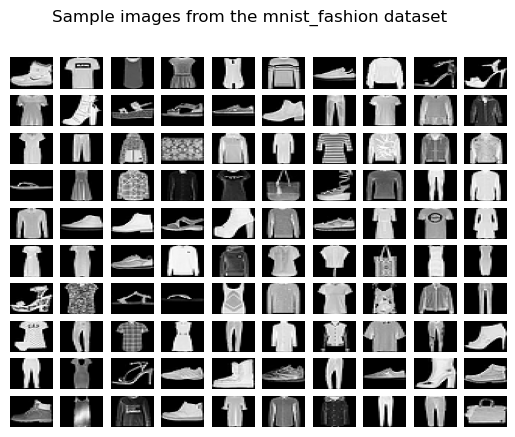

In [59]:
fig, ax = plt.subplots(10, 10)
k = 0
for i in range(10):
    for j in range(10):
        ax[i][j].imshow(x_train[k].reshape(28, 28), aspect='auto', cmap='gray')
        ax[i][j].axis('off')
        k += 1
fig.suptitle("Sample images from the mnist_fashion dataset")
plt.show()

In [60]:
activations = {
    'sigmoid': 'sigmoid',
    'relu': 'relu',
    'elu': 'elu',
    'selu': 'selu'
}

In [70]:
results = {}
for name, act in activations.items():
    print(f"Building and training with activation: {name} ({act})")
    model = Sequential([
        Flatten(input_shape=(28, 28)),
        Dense(128, activation=act),
        *[Dense(64, activation=act) for _ in range(100)],
        Dense(10, activation='softmax'),
    ])
    model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'],

                  )
    history = model.fit(x_train, y_train,
                        epochs=5,
                        batch_size=32,
                        validation_split=0.2,

                        )
    test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
    results[name] = {'acc': test_acc, 'val_acc': history.history['val_accuracy'][-1]}

    print("Test Acc:", {k: f"{v['acc']:.3f}" for k, v in results.items()})
    print(history)

Building and training with activation: sigmoid (sigmoid)
Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 14s 5ms/step - accuracy: 0.0983 - loss: 2.3095 - val_accuracy: 0.1003 - val_loss: 2.3049
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.1011 - loss: 2.3068 - val_accuracy: 0.1003 - val_loss: 2.3053
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.0971 - loss: 2.3054 - val_accuracy: 0.0995 - val_loss: 2.3039
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.0983 - loss: 2.3041 - val_accuracy: 0.1030 - val_loss: 2.3035
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.0986 - loss: 2.3032 - val_accuracy: 0.1003 - val_loss: 2.3031
Test Acc: {'sigmoid': '0.100'}
Building and training with activation: relu (relu)
Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 17s 5ms/step - accuracy: 0.0979 - loss: 2.3028 - val_accuracy: 0.0995 - val_loss: 2.3026
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.1006 - loss: 2.302

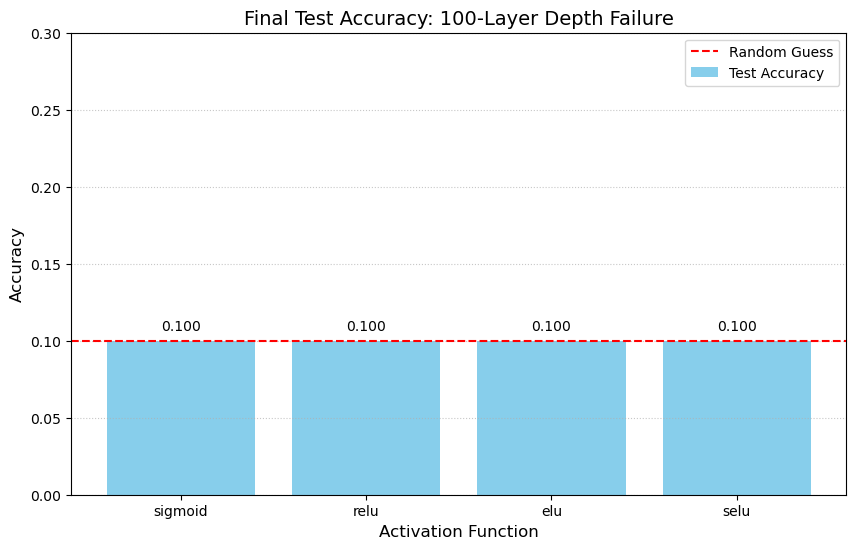

In [78]:
import matplotlib.pyplot as plt

names = list(results.keys())
test_accuracies = [results[name]['acc'] for name in names]
val_accuracies = [results[name]['val_acc'] for name in names]

plt.figure(figsize=(10, 6))

bars = plt.bar(names, test_accuracies, color='skyblue', label='Test Accuracy')

plt.axhline(y=0.10, color='red', linestyle='--', label='Random Guess')


plt.title('Final Test Accuracy: 100-Layer Depth Failure', fontsize=14)
plt.xlabel('Activation Function', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.ylim(0, 0.3)
plt.legend()


for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, yval + 0.005, f'{yval:.3f}', ha='center', va='bottom')

plt.grid(axis='y', linestyle=':', alpha=0.7)
plt.show()

Sigmoid: This function triggers severe vanishing gradients because its maximum derivative is only 0.25, meaning the error signal is multiplied by at most 1/4 at every layer until it effectively disappears before reaching the input.

ReLU: While it avoids saturation for positive values, it often leads to "dying neurons" where layers output zero and stop updating entirely, or it causes exploding gradients because the outputs are not capped.

ELU: It attempts to fix the "dying" issue by allowing negative values with a smooth gradient, but in a 100-layer stack without normalization, it still suffers from extreme instability and shift in mean activations.

SELU: This is the only function designed to be self-normalizing to prevent both vanishing and exploding gradients, though it requires a specific initializer (LeCun Normal) to maintain a mean of 0 and variance of 1 across such extreme depth.